<a href="https://colab.research.google.com/github/Tawhidrahman292/Data-science-and-Ai-ml-Tasks/blob/main/class17hw_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

# Print TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [3]:
# 1. Upload kaggle.json
from google.colab import files

files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"tawhidrahman292","key":"c793e74715d0cef03bd9c4584a5b1bcb"}'}

In [4]:
!kaggle datasets download -d moltean/fruits --unzip

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 7.10G/7.10G [00:59<00:00, 129MB/s]



In [5]:
dataset_path = "/content/fruits-360_100x100/fruits-360"

# Datasets folder/file
print(os.listdir(dataset_path))

['README.md', 'Test', 'LICENSE', 'Training']


In [6]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Test")

print("Number of classes:", len(os.listdir(train_path)))
print("Training classes:", os.listdir(train_path)[:10])

Number of classes: 260
Training classes: ['Quince 3', 'Potato Sweet 1', 'Hazelnut 1', 'Tomato 11', 'Grape Blue 1', 'Rambutan 1', 'Mulberry 1', 'Tomato 5', 'Tomato 2', 'Plum 3']


In [7]:

train_path = "/content/fruits-360_100x100/fruits-360/Training"

classes = sorted(os.listdir(train_path))

print("Total classes:", len(classes))
print("\nFirst 50 classes:")
for cls in classes[:50]:
    print(repr(cls))

Total classes: 260

First 50 classes:
'Almonds 1'
'Apple 10'
'Apple 11'
'Apple 12'
'Apple 13'
'Apple 14'
'Apple 17'
'Apple 18'
'Apple 19'
'Apple 20'
'Apple 21'
'Apple 22'
'Apple 23'
'Apple 5'
'Apple 6'
'Apple 7'
'Apple 8'
'Apple 9'
'Apple Braeburn 1'
'Apple Crimson Snow 1'
'Apple Golden 1'
'Apple Golden 2'
'Apple Golden 3'
'Apple Granny Smith 1'
'Apple Pink Lady 1'
'Apple Red 1'
'Apple Red 2'
'Apple Red 3'
'Apple Red Delicious 1'
'Apple Red Yellow 1'
'Apple Red Yellow 2'
'Apricot 1'
'Avocado 1'
'Avocado 2'
'Avocado Black 1'
'Avocado Black 2'
'Avocado Green 1'
'Banana 1'
'Banana 3'
'Banana 4'
'Banana Lady Finger 1'
'Banana Red 1'
'Bean pod 1'
'Beetroot 1'
'BlackBerry 4'
'Blackberry 1'
'Blackberry 2'
'Blackberry 3'
'Blackberry 5'
'Blueberry 1'


In [8]:
selected_classes = [
    "Apple Red 1",
    "Banana 1",
    "Grape White 1",
    "Mango 1",
    "Orange 1",
    "Strawberry 1",
    "Tomato 1",
    "Watermelon 1",
    "Pear 1",
    "Pineapple 1"
]

for cls in selected_classes:
    path = os.path.join(train_path, cls)
    print(cls, "->", os.path.exists(path))


Apple Red 1 -> True
Banana 1 -> True
Grape White 1 -> True
Mango 1 -> True
Orange 1 -> True
Strawberry 1 -> True
Tomato 1 -> True
Watermelon 1 -> True
Pear 1 -> True
Pineapple 1 -> True


In [10]:
class_names = selected_classes

IMG_HEIGHT = 100
IMG_WIDTH = 100
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    class_names=selected_classes
)

print(class_names)
print(train_ds)

Found 5128 files belonging to 10 classes.
['Apple Red 1', 'Banana 1', 'Grape White 1', 'Mango 1', 'Orange 1', 'Strawberry 1', 'Tomato 1', 'Watermelon 1', 'Pear 1', 'Pineapple 1']
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


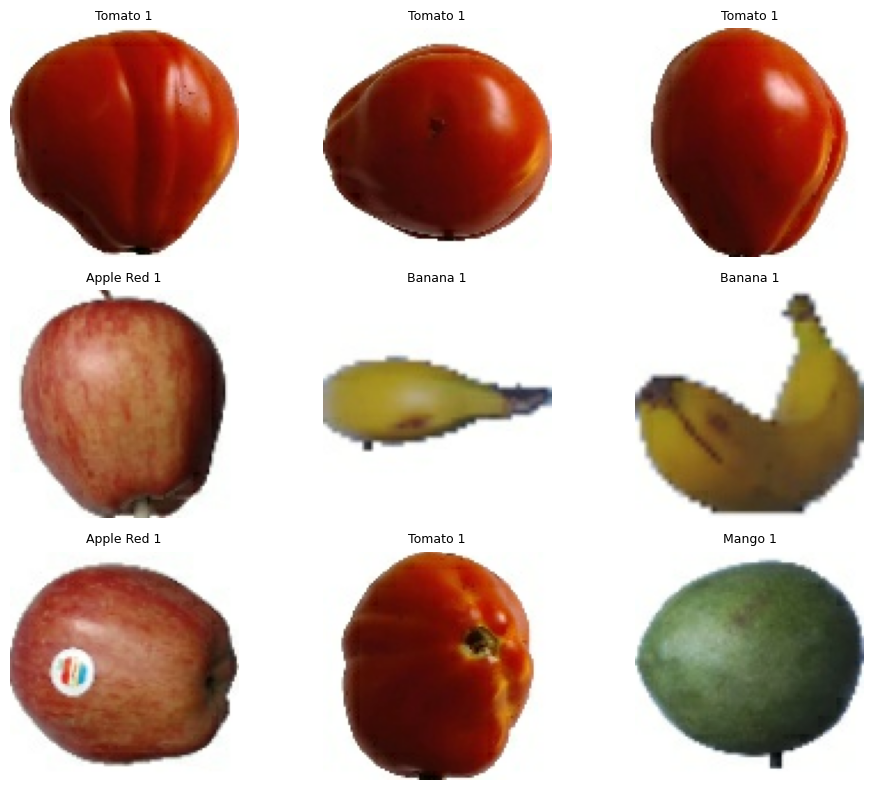

In [15]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        # Integer label → class name
        plt.title(class_names[labels[i].numpy()], fontsize=9)

        plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
IMG_SIZE = (224, 224)
num_classes = len(class_names)

print("Number of classes:", num_classes)

Number of classes: 10


In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    class_names=selected_classes
)

Found 5128 files belonging to 10 classes.


In [18]:
def build_model(base_model_class, name):

    base = base_model_class(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,)
    )

    # Pre-trained layers freeze
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name=name)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [19]:
resnet_model = build_model(
    keras.applications.ResNet50,
    "ResNet50"
)

densenet_model = build_model(
    keras.applications.DenseNet121,
    "DenseNet121"
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
EPOCHS = 5
print(">>> Training ResNet50...")
resnet_hist = resnet_model.fit(train_ds, epochs=EPOCHS)

print("\n>>> Training DenseNet121...")
densenet_hist = densenet_model.fit(train_ds, epochs=EPOCHS)

>>> Training ResNet50...
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - accuracy: 0.9696 - loss: 0.1076
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 1.0000 - loss: 0.0011
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 1.0000 - loss: 9.6791e-04
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 1.0000 - loss: 4.4760e-04

>>> Training DenseNet121...
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 60s 175ms/step - accuracy: 0.8399 - loss: 1.0758
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 49s 81ms/step - accuracy: 0.9865 - loss: 0.0537
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.9936 - loss: 0.0283
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.9955 - loss: 0.0201
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.9973 - loss: 0.0139


In [23]:
from sklearn.metrics import classification_report

# Define test_ds
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42,
    class_names=selected_classes
)

def evaluate(model, dataset, name):
    """Evaluate model and print detailed metrics."""

    # Basic evaluation
    loss, acc = model.evaluate(dataset, verbose=0)

    y_true = []
    y_pred = []

    # Collect actual and predicted labels
    for imgs, lbls in dataset:
        preds = model.predict(imgs, verbose=0)

        # Predicted class
        y_pred.extend(np.argmax(preds, axis=1))

        # Actual class
        y_true.extend(lbls.numpy())

    print("\n" + "=" * 50)
    print(f"{name}")
    print("=" * 50)

    print(f"Test Loss     : {loss:.4f}")
    print(f"Test Accuracy : {acc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    return {
        "loss": loss,
        "accuracy": acc
    }


# Evaluate ResNet50
r = evaluate(
    resnet_model,
    test_ds,
    "ResNet50"
)

# Evaluate DenseNet121
d = evaluate(
    densenet_model,
    test_ds,
    "DenseNet121"
)


# Compare both models
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)

print(f"{'Metric':<15} {'ResNet50':<15} {'DenseNet121':<15}")
print("-" * 45)

print(f"{'Accuracy':<15} {r['accuracy']:<15.4f} {d['accuracy']:<15.4f}")
print(f"{'Loss':<15} {r['loss']:<15.4f} {d['loss']:<15.4f}")

Found 1719 files belonging to 10 classes.

ResNet50
Test Loss     : 0.0006
Test Accuracy : 1.0000

Classification Report:
               precision    recall  f1-score   support

  Apple Red 1       1.00      1.00      1.00       164
     Banana 1       1.00      1.00      1.00       166
Grape White 1       1.00      1.00      1.00       166
      Mango 1       1.00      1.00      1.00       166
     Orange 1       1.00      1.00      1.00       160
 Strawberry 1       1.00      1.00      1.00       164
     Tomato 1       1.00      1.00      1.00       246
 Watermelon 1       1.00      1.00      1.00       157
       Pear 1       1.00      1.00      1.00       164
  Pineapple 1       1.00      1.00      1.00       166

     accuracy                           1.00      1719
    macro avg       1.00      1.00      1.00      1719
 weighted avg       1.00      1.00      1.00      1719


DenseNet121
Test Loss     : 0.0001
Test Accuracy : 1.0000

Classification Report:
               precisi

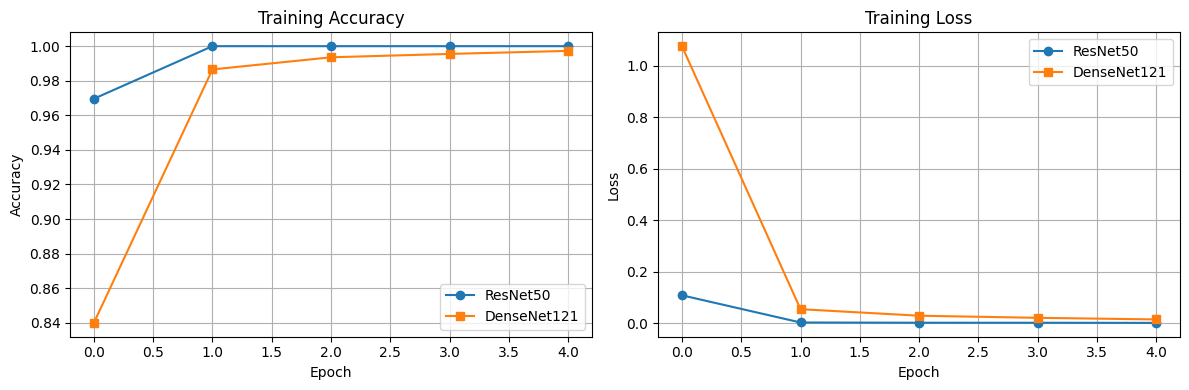

In [24]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    resnet_hist.history['accuracy'],
    marker='o',
    label='ResNet50'
)

plt.plot(
    densenet_hist.history['accuracy'],
    marker='s',
    label='DenseNet121'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    resnet_hist.history['loss'],
    marker='o',
    label='ResNet50'
)

plt.plot(
    densenet_hist.history['loss'],
    marker='s',
    label='DenseNet121'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

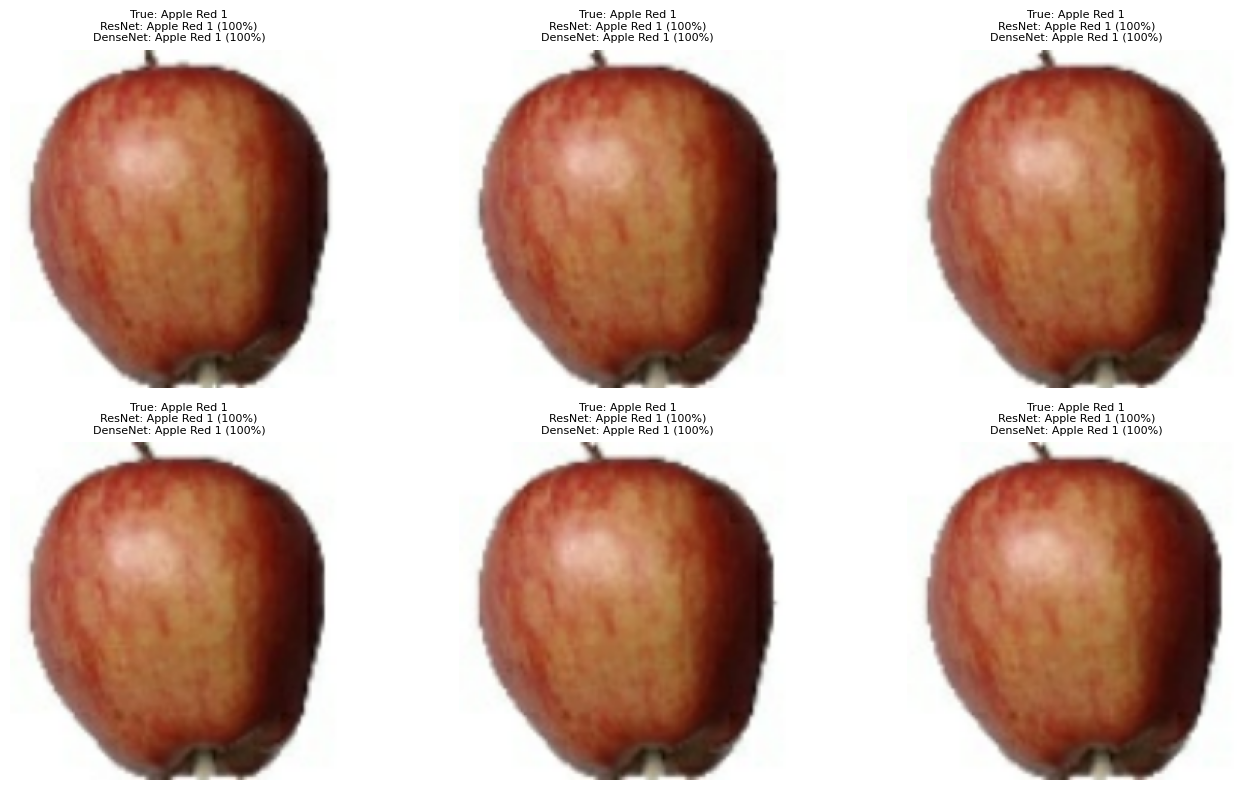

In [25]:
for test_imgs, test_lbls in test_ds.take(1):

    # Predictions
    res_preds = resnet_model.predict(test_imgs, verbose=0)
    den_preds = densenet_model.predict(test_imgs, verbose=0)

    plt.figure(figsize=(14, 8))

    for i in range(min(6, len(test_imgs))):

        plt.subplot(2, 3, i + 1)

        # Show image
        plt.imshow(test_imgs[i].numpy().astype("uint8"))

        # Actual class
        true = class_names[test_lbls[i].numpy()]

        # ResNet prediction
        r_cls = class_names[np.argmax(res_preds[i])]

        # DenseNet prediction
        d_cls = class_names[np.argmax(den_preds[i])]

        # Prediction confidence
        r_conf = np.max(res_preds[i]) * 100
        d_conf = np.max(den_preds[i]) * 100

        plt.title(
            f"True: {true}\n"
            f"ResNet: {r_cls} ({r_conf:.0f}%)\n"
            f"DenseNet: {d_cls} ({d_conf:.0f}%)",
            fontsize=8
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()